# 07 · Simulated vs observed

Compare simulated Gainesville maize yield and growth with stock measured data, and describe agreement without changing the model.

## You will learn

- Read end-of-season and dated measurements from a FileA and FileT.
- Match observations to simulated treatments and dates, then interpret comparison statistics.
- Plot measured growth alongside simulation curves and compare grain yield on a scatter plot.

In [1]:
LESSON = "07_simulated_vs_observed"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Run all six stock treatments and show grain dry weight (`HWAM`, kg dry matter/ha), anthesis (`ADAT`) and maturity (`MDAT`).

In [4]:
# Run the copied FileX and display end-of-season results.
filex = RUNS / "UFGA8201.MZX"
result = dl.run(filex, executable=dssat)
summary = dl.read_summary(result.run_dir)
display(dl.to_dataframe(summary)[["TRNO", "TNAM", "HWAM", "ADAT", "MDAT"]])

,TRNO,TNAM,HWAM,ADAT,MDAT
0,1,RAINFED LOW NITROGEN,2293,1982-05-13,1982-07-04
1,2,RAINFED HIGH NITROGEN,2293,1982-05-13,1982-07-04
2,3,IRRIGATED LOW NITROGEN,8207,1982-05-13,1982-07-04
3,4,IRRIGATED HIGH NITROGEN,11854,1982-05-13,1982-07-04
4,5,VEG STRESS LOW NITROGEN,7718,1982-05-13,1982-07-04
5,6,VEG STRESS HIGH NITROGEN,10293,1982-05-13,1982-07-04


Read the copied FileA and FileT to preview measured yield, dates and daily growth.

In [5]:
# Read and preview the measured values.
observed_a = dl.read_dssat_observed(RUNS / "UFGA8201.MZA")
observed_t = dl.read_dssat_observed(RUNS / "UFGA8201.MZT")
display(dl.to_dataframe(observed_a)[["treatment", "HWAM", "ADAT", "MDAT"]])
display(dl.to_dataframe(observed_t)[["treatment", "date", "LAID", "GWAD", "CWAD"]].head())

,treatment,HWAM,ADAT,MDAT
0,1,2929.0,1982-05-12,1982-07-04
1,2,3130.0,1982-05-12,1982-07-04
2,3,6850.0,1982-05-12,1982-07-04
3,4,11881.0,1982-05-12,1982-07-04
4,5,6375.0,1982-05-12,1982-07-04
5,6,9344.0,1982-05-12,1982-07-04


,treatment,date,LAID,GWAD,CWAD
0,1,1982-02-26,0.00,0.0,0.0
1,1,1982-03-30,0.17,0.0,88.0
2,1,1982-04-13,0.56,0.0,341.0
3,1,1982-04-26,1.43,0.0,1070.0
4,1,1982-05-11,2.26,0.0,3017.0


🌱 Crop idea  
FileA holds end-of-season measurements; FileT holds dated measurements, with `LAID` in m² leaf/m² ground and `GWAD`/`CWAD` in kg dry matter/ha.
The reader omits unmeasured `-99` values and unsupported columns; keep the matching FileX beside these files so short dates resolve to 1982.

Evaluate all FileA and FileT rows, then show the dated observations outside the simulated season.

In [6]:
# Evaluate every measured row and display the exclusions reported by the API.
evaluation = dl.evaluate(result, observed_a + observed_t)
print(f"{len(observed_t) - len(evaluation.excluded)} of {len(observed_t)} dated measurements fall inside the simulated seasons; "
      f"{len(evaluation.excluded)} are excluded")
display(dl.to_dataframe(evaluation.excluded)[["treatment", "date", "reason"]])

72 of 78 dated measurements fall inside the simulated seasons; 6 are excluded


,treatment,date,reason
0,1,1982189,after the last simulated day 1982-07-04 (1982185)
1,2,1982189,after the last simulated day 1982-07-04 (1982185)
2,3,1982189,after the last simulated day 1982-07-04 (1982185)
3,4,1982189,after the last simulated day 1982-07-04 (1982185)
4,5,1982189,after the last simulated day 1982-07-04 (1982185)
5,6,1982189,after the last simulated day 1982-07-04 (1982185)


🐍 Python idea: `evaluation.excluded` lists each out-of-range row and its simulated boundary; `1982189` means day 189 of 1982, or 8 July.
Growth output ends on 4 July, so those six measurements contribute no pairs or statistics; a missing day inside the simulated range still raises a check error.

Show the six yield errors from the Evaluation as simulated minus observed.

In [7]:
# Display the six end-of-season yield pairs.
pairs = evaluation.to_dataframe()
display(pairs.loc[pairs["variable"] == "HWAM", ["treatment", "observed", "simulated", "error"]].reset_index(drop=True))

,treatment,observed,simulated,error
0,1,2929.0,2293.0,-636.0
1,2,3130.0,2293.0,-837.0
2,3,6850.0,8207.0,1357.0
3,4,11881.0,11854.0,-27.0
4,5,6375.0,7718.0,1343.0
5,6,9344.0,10293.0,949.0


Show statistics for yield, development dates, LAI and grain weight, pooled across treatments in each variable's units.

In [8]:
# Display the five comparison variables with their native units.
units = {"HWAM": "kg/ha", "ADAT": "days", "MDAT": "days",
         "LAID": "m² leaf/m² ground", "GWAD": "kg/ha"}
statistics = [{"Variable": variable, "Unit": unit, **evaluation.statistics[variable]}
              for variable, unit in units.items()]
display(dl.to_dataframe(statistics).round(3))

,Variable,Unit,n,rmse,bias,d_index
0,HWAM,kg/ha,6,970.523,358.167,0.980
1,ADAT,days,6,1.000,1.000,0.000
2,MDAT,days,6,0.000,0.000,1.000
3,LAID,m² leaf/m² ground,72,0.502,-0.081,0.953
4,GWAD,kg/ha,72,497.640,131.583,0.992


- `n`: the number of matched measured–simulated pairs, pooled across treatments and dates for each variable.
- `rmse`: root mean squared error; smaller is closer, in the variable's units (calendar days for dates).
- `bias`: mean simulated minus observed; negative means underprediction and positive means overprediction.
- `d_index`: Willmott's index of agreement, from 0 to 1; closer to 1 indicates better agreement, and it has no units.

Yield RMSE is 970.523 kg/ha and bias is +358.167 kg/ha across the six treatments.
The rainfed low- and high-N simulations both yield 2,293 kg/ha, while their measured yields differ; yield alone does not explain that mismatch.

🌱 Crop idea  
Anthesis has a surprising d-index of 0 despite just a +1 day error: all six observed dates are identical, so any error with constant observations gives d-index 0 ([evaluation guide](../../docs/guide/evaluate.md)).
Maturity matches exactly (RMSE 0 days, d-index 1); neither date comparison identifies a cause of error or demonstrates performance on an independent experiment.

Plot LAI with all measured dates, including excluded points, to compare canopy development over time.

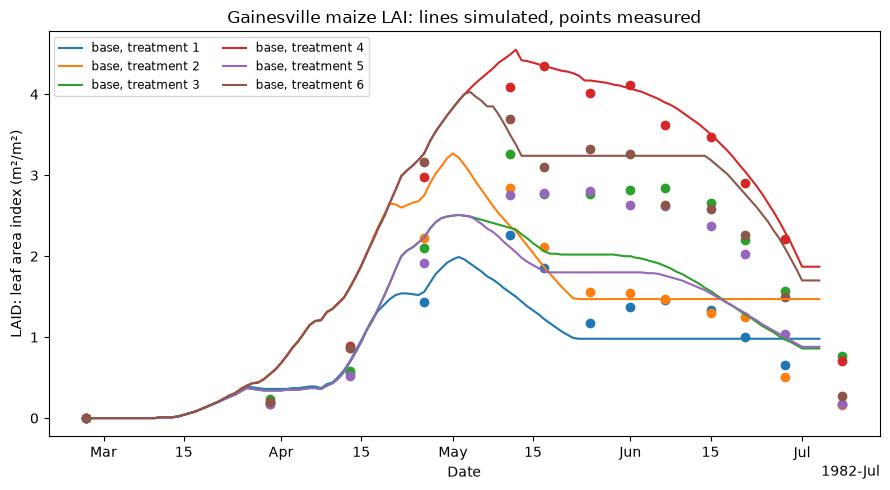

In [9]:
# Overlay measured leaf area index on simulated growth curves.
ax = dl.plot_observed(result, observed_t, "LAID")
ax.figure.set_size_inches(9, 5)
ax.set_title("Gainesville maize LAI: lines simulated, points measured")
plt.tight_layout()
plt.show()

Plot grain weight with all measured dates so measurements beyond simulated growth remain visible.

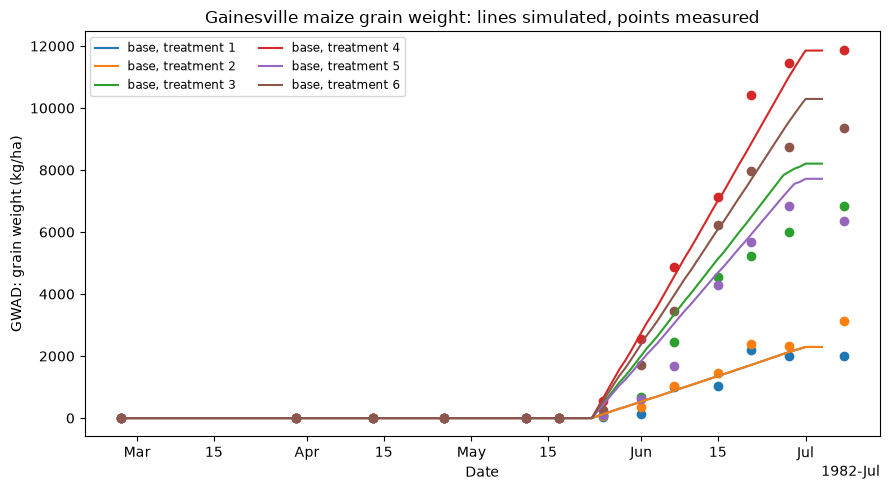

In [10]:
# Overlay measured grain dry weight on simulated growth curves.
ax = dl.plot_observed(result, observed_t, "GWAD")
ax.figure.set_size_inches(9, 5)
ax.set_title("Gainesville maize grain weight: lines simulated, points measured")
plt.tight_layout()
plt.show()

Plot the six yield pairs against the dashed 1:1 line, where simulated and observed grain yield are equal.

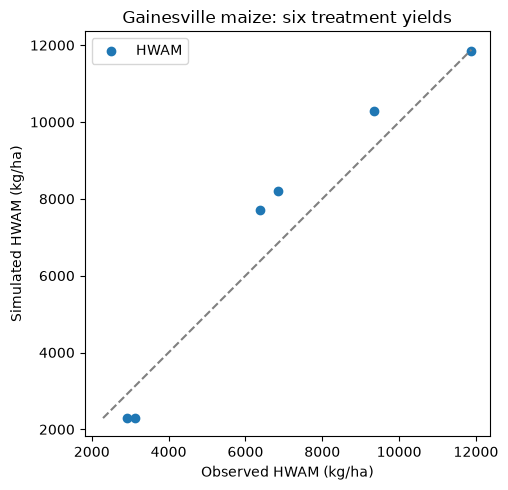

In [11]:
# Plot end-of-season grain yield agreement.
ax = dl.plot_evaluation(evaluation, variable="HWAM")
ax.figure.set_size_inches(6, 5)
ax.set_title("Gainesville maize: six treatment yields")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Your turn

Evaluate another daily growth variable and show its comparison statistics.

Hint: edit `variable = "CWAD"` (aboveground dry biomass, kg/ha); you can also choose `"LAID"` or `"GWAD"`, then run this cell.

In [12]:
# Rebuild the comparison for your chosen daily growth variable.
variable = "CWAD"
exercise_result = dl.run(RUNS / "UFGA8201.MZX", executable=dssat)
exercise_observed = dl.read_dssat_observed(RUNS / "UFGA8201.MZT")
exercise_evaluation = dl.evaluate(exercise_result, exercise_observed)
exercise_unit = "m² leaf/m² ground" if variable == "LAID" else "kg/ha"
print("Excluded dated observations:", len(exercise_evaluation.excluded))
display(dl.to_dataframe([{"Variable": variable, "Unit": exercise_unit,
                         **exercise_evaluation.statistics[variable]}]).round(3))

Excluded dated observations: 6


,Variable,Unit,n,rmse,bias,d_index
0,CWAD,kg/ha,72,828.849,141.819,0.995


## Recap

- `read_dssat_observed()` reads measured values without treating missing `-99` entries as numbers.
- `evaluate()` reports observations outside the simulated range in `excluded`; interpret matched errors in each variable's units.
- `plot_observed()` compares growth curves with measurements, while `plot_evaluation()` shows agreement against a 1:1 line.

Next: [08 · A new cultivar](../08_new_cultivar/lesson.ipynb).